In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import util.functions as functions
from models.FNO import CAPE_FNO
import pybamm
import flax

In [2]:
from skopt.utils import use_named_args
from skopt.space import Real
from skopt import gp_minimize

In [3]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
# from util.plotting import create_plot_FNO_results, create_plot_voltage
from util.postprocess import filter_anode_cathode, calc_error_metrics, calc_error_metrics_all
from inference.parameter_estimation import get_jnp_U_OCP_anode, get_jnp_U_OCP_cathode

In [4]:
family = "GRF"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
split_seed = 42
test_ratio = 0.1

In [5]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)
U_OCP_an = get_jnp_U_OCP_anode(parameter_name)
U_OCP_ca = get_jnp_U_OCP_cathode(parameter_name)


C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]

EPS = 1e-12
t_max = 3600

In [6]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=split_seed)  # noqa: F405

In [7]:
func_I = np.array(test_data["current"])

### Anode data ###
cn_anode = np.array(test_data["cn_anode"])
c0_anode = np.array(test_data["c0_anode"])
D_anode = np.array(test_data["Dan"])

### Cathode data ###
cn_cathode = np.array(test_data["cn_cathode"])
c0_cathode = np.array(test_data["c0_cathode"])
D_cathode = np.array(test_data["Dca"])

soc = np.array(test_data["soc"])

In [8]:
D_anode = normalise_diffusion(D_anode)
D_cathode = normalise_diffusion(D_cathode)

In [9]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)
cs_max_a_norm = 1 #params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c_norm = 1 #params_bat["Maximum concentration in positive electrode [mol.m-3]"]
cs_min_a_norm = 0.0
cs_min_c_norm = 0.0

In [10]:
cn_anode, cn_cathode, mask = filter_anode_cathode(cn_anode, cn_cathode,
                                                    anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                    cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [11]:
func_I = func_I[mask]
c0_anode = c0_anode[mask]
c0_cathode = c0_cathode[mask]
D_anode = D_anode[mask]
D_cathode = D_cathode[mask]
soc = soc[mask]

In [12]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [13]:
X_anode, Y_anode = preprocess_data(func_I, c0_anode, cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_cathode, Y_cathode = preprocess_data(func_I, c0_cathode, cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [14]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
input_channels = 4 # We should automate this TODO
output_channels = 1
cape_hidden_size = 32

In [15]:
N_test = func_I.shape[0]
rng = np.random.default_rng(split_seed)
test_idx = 7 #rng.integers(0, N_test)

In [46]:
model = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, 
                 fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, 
                 hidden_channels=hidden_channels, output_channels=output_channels)

main_key = jax.random.PRNGKey(split_seed)
# Initialize parameters
dummy_D = jax.random.normal(main_key, (1,1))
params = model.init(main_key, X_anode[:1,...], dummy_D)

# Forward pass
out = model.apply(params, X_anode[:1,...], dummy_D)

In [47]:
anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_17-11-44.msgpack"
cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_17-35-54.msgpack"

params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [48]:
LOG10_D_MIN, LOG10_D_MAX = -15.0, -12.0

In [49]:
R_gas = params_bat['Ideal gas constant [J.K-1.mol-1]']
F = params_bat['Faraday constant [C.mol-1]']
Temp = params_bat["Ambient temperature [K]"]

In [50]:
V_pred_list = []
c_an_surf_list = []
c_ca_surf_list = []

In [ ]:
def calc_voltage(params_bat, c_an_surf, c_ca_surf, func_I,):
    # Calculate the anode and cathode OCPs
    c_an_surf = jnp.clip(c_an_surf, EPS, 1-EPS)
    c_ca_surf = jnp.clip(c_ca_surf, EPS, 1-EPS)

    j_anode   = jnp.sqrt(c_an_surf * (1.0 - c_an_surf))
    j_cathode = jnp.sqrt(c_ca_surf * (1.0 - c_ca_surf))

    xan = functions.in_arcsinh(-func_I, Ran, epsan, Lan, A)
    xca = functions.in_arcsinh(-func_I, Rca, epsca, Lca, A)

    V_pred = U_OCP_ca(c_ca_surf) - U_OCP_an(c_an_surf) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xan/(j_anode)) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xca/(j_cathode))

    return V_pred

In [52]:
kan = Ran / (3 * epsan * Lan * A)
kca = Rca / (3 * epsca * Lca * A)
RTF = 2 * R_gas*Temp/F

In [53]:
def inference_concentration_norm(X_anode_truth, X_cathode_truth, D_anode_candidate, D_cathode_candidate):
    
    cn_anode = model.apply(params_anode,X_anode_truth, D_anode_candidate)
    cn_cathode = model.apply(params_cathode,X_cathode_truth, D_cathode_candidate)

    cn_anode_reshape = remove_padding(cn_anode, padding_r = padding_r, padding_t = padding_t)
    cn_cathode_reshape = remove_padding(cn_cathode, padding_r = padding_r, padding_t = padding_t)

    return cn_anode_reshape, cn_cathode_reshape

In [54]:
@jax.jit
def inference_step(func_I_truth, X_anode_truth, X_cathode_truth, D_anode_candidate, D_cathode_candidate):
    cn_anode = model.apply(params_anode,X_anode_truth, D_anode_candidate)
    cn_cathode = model.apply(params_cathode,X_cathode_truth, D_cathode_candidate)

    cn_anode_reshape = remove_padding(cn_anode, padding_r = padding_r, padding_t = padding_t)
    cn_cathode_reshape = remove_padding(cn_cathode, padding_r = padding_r, padding_t = padding_t)

    cn_anode_surf = cn_anode_reshape[:, -1, :, 0].clip(EPS, 1.0 - EPS)
    cn_cathode_surf = cn_cathode_reshape[:, -1, :, 0].clip(EPS, 1.0 - EPS)

    j_anode   = jnp.sqrt(cn_anode_surf * (1.0 - cn_anode_surf))
    j_cathode = jnp.sqrt(cn_cathode_surf * (1.0 - cn_cathode_surf))

    xan = -func_I_truth * kan
    xca = -func_I_truth * kca

    V_pred = U_OCP_ca(cn_cathode_surf) - U_OCP_an(cn_anode_surf) - RTF * jnp.arcsinh(0.5*xan/(j_anode)) - RTF * jnp.arcsinh(0.5*xca/(j_cathode))
    return V_pred

In [55]:
# ---- design space ----------------------------------------
dimensions = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca"),
]

In [56]:
V_data = functions.post_proc_true(params_bat, func_I[test_idx], cn_anode[test_idx,-1,:], cn_cathode[test_idx,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
assert np.isfinite(V_data).all()

In [57]:
@jax.jit
def calc_rmse(V_pred, V_data):
    rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
    return rmse

@jax.jit
def calc_rel_ls(V_pred, V_data):
    rel_l2 = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2)) / jnp.sqrt(jnp.mean(V_data ** 2))
    return rel_l2

In [58]:
normalise_diffusion = jax.jit(normalise_diffusion)

In [59]:
@use_named_args(dimensions)
def obj_voltage(log10_Dan, log10_Dca):
    # --- 1.  normalise the candidate diffusivities ------------
    log10_Dan_norm = normalise_diffusion(jnp.array(log10_Dan).reshape(-1,1))
    log10_Dca_norm = normalise_diffusion(jnp.array(log10_Dca).reshape(-1,1))
    # --- 2.  CAPE-FNO predictions of c(r,t) ---------------
    V_pred = inference_step(func_I[test_idx],
        X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
        log10_Dan_norm, log10_Dca_norm
    )
    #V_pred_list.append(V_pred)

    # --- 4.  voltage RMSE (you can use MAE or any other scalar) -------------
    rmse = calc_rel_ls(V_pred, V_data)
    
    return float(rmse)

In [60]:
res = gp_minimize(
    obj_voltage,
    dimensions=dimensions,
    n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
    n_initial_points=12,   # random Sobol/Bach search first
    acq_func="EI",         # expected improvement
    random_state=0,
)

best_log10_Dan, best_log10_Dca = res.x
print(f"Best log10(Dan) = {best_log10_Dan:.3f}")
print(f"Best log10(Dca) = {best_log10_Dca:.3f}")
print(f"Voltage-curve RMSE = {res.fun:.4e}")

Best log10(Dan) = -14.041
Best log10(Dca) = -13.943
Voltage-curve RMSE = 2.1162e-03


In [82]:
V_best_cape_fno_from_cape_fno = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    normalise_diffusion(jnp.array(best_log10_Dan).reshape(-1,1)), normalise_diffusion(jnp.array(best_log10_Dca).reshape(-1,1))
)
# print(f"Best voltage prediction: {V_best}")

In [83]:
log_Dan_true = float(D_anode[test_idx])
log_Dca_true = float(D_cathode[test_idx])

In [84]:
def unnormalise_diffusion(log10_D):
    return (log10_D +1)/2*(LOG10_D_MAX-LOG10_D_MIN) + LOG10_D_MIN

In [85]:
log_Dan_true = unnormalise_diffusion(log_Dan_true)
log_Dca_true = unnormalise_diffusion(log_Dca_true)

In [86]:
V_test_pred = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    D_anode[test_idx][None, ...].reshape(-1,1), D_cathode[test_idx][None, ...].reshape(-1,1)
)

assert np.isclose(V_test_pred, V_data, rtol=1e-1).all(), "Test prediction does not match the data!"

In [87]:
# ---- design space ----------------------------------------
dimensions_pybamm = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan_pybamm"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca_pybamm"),
]

In [88]:
import pybamm
import numpy as np

# ▶  a baseline Li-ion model  (SPMe is fast; swap for DFN if you prefer)
pybamm_model = pybamm.lithium_ion.SPM()
pybamm_model.events = []

# ▶  time grid that matches your measured voltage trace V_true
t_eval = np.linspace(0, 3600, 75)   # dt = sample spacing [s]

# ▶  current profile: use your measured current array `func_I`
#     (shape (T,)).  Convert to an interpolant so PyBaMM can call it at any t.
current_fun = pybamm.Interpolant(t_eval, -func_I[test_idx].squeeze(), pybamm.t)

#     Tell the model to use that function instead of the built-in C-rate
params_bat["Current function [A]"] = current_fun

In [89]:
@use_named_args(dimensions_pybamm)
def obj_voltage_pybamm(log10_Dan_pybamm, log10_Dca_pybamm):

    try:
        # --- 1.  normalise the candidate diffusivities ------------
        D_anode_candidate = 10 ** log10_Dan_pybamm
        D_cathode_candidate = 10 ** log10_Dca_pybamm

        params_bat["Negative particle diffusivity [m2.s-1]"] = D_anode_candidate
        params_bat["Positive particle diffusivity [m2.s-1]"] = D_cathode_candidate

        sim = pybamm.Simulation(pybamm_model, parameter_values=params_bat)
        sim.solve(initial_soc = soc[0], t_eval=t_eval)

        #V_pred = sim.solution["Terminal voltage [V]"](t_eval)

        c_an_surf = sim.solution["Negative particle concentration [mol.m-3]"].entries[-1,0, :]
        c_ca_surf = sim.solution["Positive particle concentration [mol.m-3]"].entries[-1,0, :]
        # --- 3.  voltage RMSE (you can use MAE or any other scalar) -------------
        V_pred = calc_voltage(params_bat, c_an_surf, c_ca_surf, func_I[test_idx])
        rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
        if np.isnan(rmse):
            return 1e8
        return float(rmse)

    except Exception as e:
        return float('1e8')


In [90]:
res_pybamm = gp_minimize(
    obj_voltage_pybamm,
    dimensions=dimensions_pybamm,
    n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
    n_initial_points=12,   # random Sobol/Bach search first
    acq_func="EI",         # expected improvement
    random_state=0,
)

best_log10_Dan_pybamm, best_log10_Dca_pybamm = res_pybamm.x
print(f"Best log10(Dan) = {best_log10_Dan_pybamm:.3f}")
print(f"Best log10(Dca) = {best_log10_Dca_pybamm:.3f}")
print(f"Voltage-curve RMSE = {res_pybamm.fun:.4e}")

Best log10(Dan) = -13.221
Best log10(Dca) = -12.467
Voltage-curve RMSE = 1.0000e+08


In [91]:
params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dan
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dca

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[test_idx], t_eval=t_eval)

c_an_pybamm_from_cape_fno = sim.solution["Negative particle concentration"].entries
c_ca_pybamm_from_cape_fno = sim.solution["Positive particle concentration"].entries

c_an_surf_pybamm_from_cape_fno = c_an_pybamm_from_cape_fno[-1, 0, :]
c_ca_surf_pybamm_from_cape_fno = c_ca_pybamm_from_cape_fno[-1, 0, :]

# V_best_pybamm_from_cape_fno = sim.solution["Local voltage [V]"](t_eval)
V_best_pybamm_from_cape_fno = calc_voltage(params_bat, c_an_surf_pybamm_from_cape_fno, c_ca_surf_pybamm_from_cape_fno, func_I[test_idx])


params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** log_Dan_true
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** log_Dca_true

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[test_idx], t_eval=t_eval)

c_an_true_pybamm = sim.solution["Negative particle concentration"].entries
c_ca_true_pybamm = sim.solution["Positive particle concentration"].entries

c_an_surf_true_pybamm = c_an_true_pybamm[-1, 0, :]
c_ca_surf_true_pybamm = c_ca_true_pybamm[-1, 0, :]

# V_true_pybamm = sim.solution["Local voltage [V]"](t_eval)
V_true_pybamm = calc_voltage(params_bat, c_an_surf_true_pybamm, c_ca_surf_true_pybamm, func_I[test_idx])


params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dan_pybamm
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dca_pybamm

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = soc[test_idx], t_eval=t_eval)
# V_best_pybamm_from_pybamm = sim.solution["Local voltage [V]"](t_eval)

c_an_pybamm_from_pybamm = sim.solution["Negative particle concentration"].entries
c_ca_pybamm_from_pybamm = sim.solution["Positive particle concentration"].entries

c_an_surf_pybamm_from_pybamm = c_an_pybamm_from_pybamm[-1, 0, :]
c_ca_surf_pybamm_from_pybamm = c_ca_pybamm_from_pybamm[-1, 0, :]

V_best_pybamm_from_pybamm = calc_voltage(params_bat, c_an_surf_pybamm_from_pybamm, c_ca_surf_pybamm_from_pybamm, func_I[test_idx])


In [92]:
V_best_cape_fno_from_pybamm = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    normalise_diffusion(jnp.array(best_log10_Dan_pybamm).reshape(-1,1)),
    normalise_diffusion(jnp.array(best_log10_Dca_pybamm).reshape(-1,1))
)

In [93]:
import matplotlib.pyplot as plt

In [94]:
V_best_cape_fno_from_cape_fno

Array([[2.1780198, 2.9001567, 3.047421 , 3.1146905, 3.1766386, 3.2179432,
        3.2368374, 3.2404025, 3.2393737, 3.2359288, 3.2312608, 3.2259147,
        3.2202556, 3.2144775, 3.2094524, 3.2046025, 3.2009087, 3.198597 ,
        3.1979814, 3.1987402, 3.200417 , 3.2027805, 3.2060814, 3.2096922,
        3.2133272, 3.216531 , 3.2203126, 3.224253 , 3.228641 , 3.2333295,
        3.2387364, 3.2447264, 3.2508116, 3.2570534, 3.2630746, 3.2694209,
        3.2750149, 3.2799447, 3.2838757, 3.2869616, 3.2891376, 3.290298 ,
        3.2905302, 3.290502 , 3.2899678, 3.289525 , 3.289068 , 3.28896  ,
        3.2890685, 3.2893715, 3.2899308, 3.2906315, 3.291514 , 3.2925906,
        3.29369  , 3.2948937, 3.296402 , 3.298147 , 3.3002906, 3.3028228,
        3.3058877, 3.309523 , 3.313588 , 3.3179002, 3.3225796, 3.327557 ,
        3.3327312, 3.3368828, 3.340124 , 3.347429 , 3.3601308, 3.369077 ,
        3.3751187, 3.3792388, 3.380471 ]], dtype=float32)

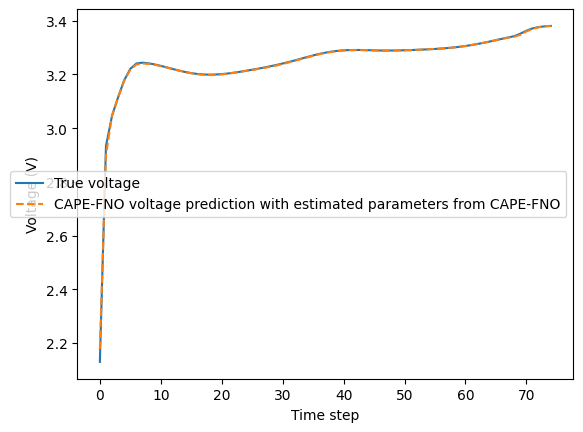

In [95]:
plt.plot(V_data, label="True voltage")
# plt.plot(V_true_pybamm, label="PyBaMM voltage results with original test sample diffusivities")

plt.plot(V_best_cape_fno_from_cape_fno.flatten(), label="CAPE-FNO voltage prediction with estimated parameters from CAPE-FNO", linestyle='--')
# plt.plot(V_best_pybamm_from_cape_fno.reshape(-1,1), label="PyBaMM voltage results with estimated parameters from CAPE-FNO", linestyle='--')


# plt.plot(V_best_pybamm_from_pybamm.reshape(-1,1), label="PyBaMM voltage results with estimated parameters from PyBaMM", linestyle=':')
# plt.plot(V_best_cape_fno_from_pybamm.reshape(-1,1), label="CAPE-FNO voltage prediction with estimated parameters from PyBaMM", linestyle=':')

plt.xlabel("Time step")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

In [96]:
mean_error = (np.abs(best_log10_Dan - log_Dan_true) + np.abs(best_log10_Dca - log_Dca_true))/2

In [97]:
mean_error_pybamm = (np.abs(best_log10_Dan_pybamm - log_Dan_true) + np.abs(best_log10_Dca_pybamm - log_Dca_true))/2

In [98]:
mean_error

np.float64(0.04033090573973741)

In [99]:
mean_error_pybamm

np.float64(1.1880407555172532)

In [100]:
#error Vdata_Vpred , conc_anode_data_vs_pred, conc_cathode_data_vs_pred all for the best parameters for both CAPE-FNO and PyBaMM

In [101]:
V_max = params_bat["Upper voltage cut-off [V]"]
V_min = params_bat["Lower voltage cut-off [V]"]

V_best_cape_fno_from_cape_fno_norm = (V_best_cape_fno_from_cape_fno - V_min) / (V_max - V_min)
V_best_pybamm_from_cape_fno_norm = (V_best_pybamm_from_cape_fno - V_min) / (V_max - V_min)
V_best_pybamm_from_pybamm_norm = (V_best_pybamm_from_pybamm - V_min) / (V_max - V_min)
V_true_pybamm_norm = (V_true_pybamm - V_min) / (V_max - V_min)
V_best_cape_fno_from_pybamm_norm = (V_best_cape_fno_from_pybamm - V_min) / (V_max - V_min)
V_data_norm = (V_data - V_min) / (V_max - V_min)


In [102]:
# concentration_errors_anode = calc_error_metrics(c_test_pred_scaled_anode, c_test_true_scaled_anode)
# concentration_errors_cathode = calc_error_metrics(c_test_pred_scaled_cathode, c_test_true_scaled_cathode)
# concentration_errors_all = calc_error_metrics_all(concentration_errors_anode, concentration_errors_cathode)
voltage_errors_cape_fno = calc_error_metrics(V_best_cape_fno_from_cape_fno, V_data, axis=(0,))
voltage_errors_pybamm_from_cape_fno = calc_error_metrics(V_best_pybamm_from_cape_fno, V_data, axis=(0,))
voltage_errors_pybamm = calc_error_metrics(V_best_pybamm_from_pybamm, V_data, axis=(0,))
voltage_errors_cape_fno_from_pybamm = calc_error_metrics(V_best_cape_fno_from_pybamm, V_data, axis=(0,))

voltage_errors_cape_fno_norm = calc_error_metrics(V_best_cape_fno_from_cape_fno_norm, V_data_norm, axis=(0,))
voltage_errors_pybamm_from_cape_fno_norm = calc_error_metrics(V_best_pybamm_from_cape_fno_norm, V_data_norm, axis=(0,))
voltage_errors_pybamm_norm = calc_error_metrics(V_best_pybamm_from_pybamm_norm, V_data_norm, axis=(0,)) 
voltage_errors_cape_fno_from_pybamm_norm = calc_error_metrics(V_best_cape_fno_from_pybamm_norm, V_data_norm, axis=(0,))


In [104]:
c_an_cape_fno_from_cape_fno, c_ca_cape_fno_from_cape_fno = inference_concentration_norm(
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    normalise_diffusion(jnp.array(best_log10_Dan).reshape(-1,1)),
    normalise_diffusion(jnp.array(best_log10_Dca).reshape(-1,1))
    )   

In [106]:
c_an_cape_fno_from_cape_fno.shape

(1, 20, 75, 1)

In [113]:
(np.abs(cn_anode[test_idx, :, :] - c_an_cape_fno_from_cape_fno.squeeze())).mean() * 100

np.float32(0.41405255)

In [114]:
cn_anode[test_idx, :, :].shape

(20, 75)